# Homework 3: Open-Ended Data Project (APIs, Merging, & Analysis)

- **Course**: Data Science for Public Policy  
- **Assignment Type**: Open-Ended Policy Research Project  

### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Crucial Project Requirements**

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.
  - Alternatively, you may upload a local file, provided it is committed to your repository.
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
- **Mandatory Local Path & Directory Structure**
  - All homework-specific datasets must be stored in the dedicated local directory: `data/hw/hw_3/`.
  - If the directory `data/hw/hw_3/` does not exist in your workspace, you must create it.
  - Any primary or secondary dataset that you download, write, or load locally must live inside `data/hw/hw_3/`.
- **Working Directory & Relative Paths**
  - Since this Jupyter notebook resides in `notebooks/hw/hw_3/`, its default working directory is set to that folder.
  - To load files using clean relative paths from the project root (like `data/hw/hw_3/my_data.csv` or `data/examples/week_5/world_happiness.parquet`), you must programmatically change your working directory to the project root at the start of your notebook.
  - In Part 1, we show you how to use `os.getcwd()` and `os.chdir()` to change your working directory. Once changed, all relative paths starting with `data/` will resolve perfectly.
  - Never hardcode absolute paths specific to your local machine (like `/Users/username/...`).
- **Reproducibility**
  - Commit both this notebook and the datasets in `data/hw/hw_3/` so that your grader can run all cells from top to bottom out-of-the-box.

---

### **Example Datasets for Selection**

To help you select an interesting topic, we have highlighted a few high-quality, policy-relevant datasets below. You are highly encouraged to explore these or check the complete menu of over 100 macroeconomic and public policy datasets available in the [Dataset Reference Guide](file:///Users/cory/Desktop/datascience-publicpolicy-2026/docs/example_datasets.md).

Here are some curated examples to consider:

1. **World Development Indicators (WDI) - World Bank**
   * **Policy Relevance**: Explore global development indicators such as GDP growth, life expectancy, inflation, and trade volumes across 200+ countries.
   * **Variables**: GDP per capita, life expectancy, inflation rate, export volumes, and foreign direct investment.

2. **World Happiness Report**
   * **Policy Relevance**: Investigate the economic and social factors that influence subjective well-being across 140+ countries.
   * **Variables**: Life satisfaction (ladder score), social support, healthy life expectancy, freedom to make life choices, generosity, and perceptions of corruption.

3. **Oxford COVID-19 Government Response Tracker (OxCGRT)**
   * **Policy Relevance**: Evaluate how government policy measures relate to public health indicators or economic outcomes across 180+ countries.
   * **Variables**: School closing, workplace closing, travel restrictions, vaccine policies, and the Stringency Index.

4. **Standardized World Income Inequality Database (SWIID)**
   * **Policy Relevance**: Compare income inequality trends and redistributive policy outcomes across countries and time.
   * **Variables**: Gini coefficient for market income, Gini coefficient for disposable income, and redistributive transfers.

5. **IMF World Economic Outlook (WEO)**
   * **Policy Relevance**: Examine macroeconomic trends, fiscal positions, and short-to-medium-term economic forecasts across 196 countries.
   * **Variables**: Real GDP growth, consumer price inflation, general government gross debt, current account balance, and unemployment rate.

For the full reference guide containing detailed information on over 100 datasets, including themes, variables, and links, please refer to:
* **Dataset Reference Guide**: [docs/example_datasets.md](file:///Users/cory/Desktop/datascience-publicpolicy-2026/docs/example_datasets.md)

---

### **Grading Criteria**

- **Data Acquisition & Environment Preparation**
  - Programmatic download or loading via committed relative paths.
  - Verification of directory structure using environment tools.
- **Cleaning & Preprocessing**
  - Standardizing names, selecting relevant subsets, and handling missing values.
- **Merging Datasets**
  - Programmatic merge on a matching key (like country code or year).
- **Aggregation & Groupby Analysis**
  - Category segmentation or custom binning for datasets without natural categories.
- **Visualization & Exploratory Modeling**
  - Beautiful, fully customized plots.
  - Regression model with slope and policy interpretation.

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup & Working Directory Alignment**
  - By default, your working directory is the folder where this notebook is located (`notebooks/hw/hw_3`).
  - To use standard project-root relative paths, you must programmatically change your working directory to the project root.
  - Use Python's `os` library (reviewed in Week 3) to check if your working directory is `notebooks/hw/hw_3` or the root. If it is `notebooks/hw/hw_3`, use `os.chdir()` to navigate up to the project root.
  - Print the aligned working directory using `os.getcwd()` and list the files in the directory using `os.listdir()` to verify that the `data/hw/hw_3/` folder is visible.
- **Local Path Validation**
  - Check if the dedicated folder `data/hw/hw_3/` exists. If it does not exist, use `os.makedirs()` to create the directory `data/hw/hw_3/` programmatically.
- **Acquisition & Storage Steps**
  - Programmatically fetch your primary dataset using `requests` or read it from a public URL.
  - Save the downloaded dataset directly into the local path: `data/hw/hw_3/` (for example, `data/hw/hw_3/primary_dataset.csv`).
  - Load the primary dataset into a Pandas DataFrame using its local path `data/hw/hw_3/primary_dataset.csv` (or the appropriate file extension) to ensure all subsequent analysis is fully local and reproducible.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [37]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

# 1. Print environment details and change the working directory to the project root.
# If the current folder is 'notebooks/hw/hw_3', change to the project root so that 'data/hw/hw_3/' is accessible via relative paths.
# Print os.getcwd() before and after the change to confirm alignment.
# Verify that the local path 'data/hw/hw_3/' exists, or create it programmatically using os.makedirs() if it does not.
# YOUR CODE HERE

initial_directory = os.getcwd()
print("Current working directory before change:", initial_directory)

project_root_name = "datascience-publicpolicy-2026"

if project_root_name in initial_directory:
    base_path = initial_directory.split(project_root_name)[0]
    final_root_path = os.path.join(base_path, project_root_name)
    os.chdir(final_root_path)

aligned_directory = os.getcwd()
print("Current working directory after change:", os.getcwd())

# 2. Acquire and load your primary dataset.
# Programmatically download your data (or load a committed local file) and save it directly inside 'data/hw/hw_3/'.
# Read the dataset from its local path 'data/hw/hw_3/your_file.csv' (or parquet/json) into a Pandas DataFrame.
# YOUR CODE HERE

df_oecd = pd.read_csv("data/hw/hw_3/oecd_education.csv")


Current working directory before change: /Users/lingsyuan/Documents/GitHub/datascience-publicpolicy-2026
Current working directory after change: /Users/lingsyuan/Documents/GitHub/datascience-publicpolicy-2026


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).
- **Policy Relevance**
  - Detail why this dataset is important for public policy decisions.
  - List the primary variables of interest for your research.

- *Write your source and relevance bullets here*

The dataset is obtained from the World Happiness Report (WHR), a landmark survey of global happiness published annually by the Sustainable Development Solutions Network (SDSN). Specifically, the primary dataset used in this analysis is the "WHR26 Data for Figure 2.1," which reflects global happiness and life evaluation metrics across countries up to the year 2025.

Traditional policy evaluation frameworks rely heavily on aggregate economic metrics, such as Gross Domestic Product (GDP) or per capita income. However, robust economic growth does not automatically translate into improved subjective well-being or individual welfare. The World Happiness Report introduces a multi-dimensional lens that shifts the focus from mere material wealth to a broader evaluation of holistic social well-being. By integrating institutional and social psychological dimensions, this framework allows policymakers to assess the qualitative performance and comprehensive health of a society.

The primary variables of interest include the dependent variable: Life Evaluation, and the independent variables: Log GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, and Perceptions of corruption.

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [38]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
df_oecd.info()
df_oecd.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 50 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   STRUCTURE                     144 non-null    object 
 1   STRUCTURE_ID                  144 non-null    object 
 2   STRUCTURE_NAME                144 non-null    object 
 3   ACTION                        144 non-null    object 
 4   REF_AREA                      144 non-null    object 
 5   Reference area                144 non-null    object 
 6   SEX                           144 non-null    object 
 7   Sex                           144 non-null    object 
 8   AGE                           144 non-null    object 
 9   Age                           144 non-null    object 
 10  ATTAINMENT_LEV                144 non-null    object 
 11  Educational attainment level  144 non-null    object 
 12  EDUCATION_FIELD               144 non-null    object 
 13  Field

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,SEX,Sex,AGE,Age,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,CONF_STATUS,Confidentiality status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
0,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,PER,Peru,_T,Total,Y25T64,From 25 to 64 years,...,39.276722,NaN,A,Normal value,NaN,NaN,0,Units,1,One
1,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,LUX,Luxembourg,_T,Total,Y25T64,From 25 to 64 years,...,28.003969,NaN,A,Normal value,NaN,NaN,0,Units,1,One
2,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,SVN,Slovenia,_T,Total,Y25T64,From 25 to 64 years,...,54.374645,NaN,A,Normal value,NaN,NaN,0,Units,1,One
3,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,TUR,Türkiye,_T,Total,Y25T64,From 25 to 64 years,...,49.924622,NaN,A,Normal value,NaN,NaN,0,Units,1,One
4,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,LVA,Latvia,_T,Total,Y25T64,From 25 to 64 years,...,40.456608,NaN,A,Normal value,NaN,NaN,0,Units,1,One


In [39]:
# 2. Rename columns and select a clean subset
# YOUR CODE HERE
selected_columns = [
    "Reference area", 
    "Educational attainment level", 
    "OBS_VALUE", 
]
df_oecd_subset = df_oecd[selected_columns].copy()
df_oecd_subset.columns = df_oecd_subset.columns.str.lower().str.replace(" ", "_")

df_oecd_subset = df_oecd_subset.rename(columns={
    "reference_area": "country",
    "obs_value": "per cent"
})

print(df_oecd_subset.head(3))

      country                       educational_attainment_level   per cent
0        Peru                                 Tertiary education  39.276722
1  Luxembourg  Upper secondary or post-secondary non-tertiary...  28.003969
2    Slovenia  Upper secondary or post-secondary non-tertiary...  54.374645


In [40]:
# 3. Handle missing values (NaNs)
# YOUR CODE HERE
df_oecd_clean = df_oecd_subset.dropna()

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Load a secondary dataset relative to the project root.
  - You can load one of the provided datasets in the Week 5 examples directory, such as `data/examples/week_5/world_happiness.parquet` or `data/examples/week_5/imf_weo_countries.parquet`.
  - Alternatively, you can programmatically download another related dataset. If you download a custom secondary dataset, save it inside your local path `data/hw/hw_3/` alongside your primary dataset.
- **Path Verification**
  - Ensure the file path used to load the secondary dataset (e.g., `data/examples/week_5/world_happiness.parquet` or `data/hw/hw_3/secondary_dataset.csv`) is relative to the project root working directory set in Part 1.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [41]:
# 1. Load and clean the secondary dataset.
# Load a dataset from 'data/examples/week_5/' (e.g., 'data/examples/week_5/world_happiness.parquet')
# or load a custom dataset saved in your local path 'data/hw/hw_3/'.
# YOUR CODE HERE
df_wb = pd.read_csv("data/hw/hw_3/worldbank_fertility.csv", skiprows=4)

df_wb_subset = df_wb[["Country Name", "2024.0"]].copy()
df_wb_subset.columns = ["country", "fertility_rate"]
print(df_wb_subset.head(3))

df_wb_clean = df_wb_subset.dropna()

                       country  fertility_rate
0                        Aruba        1.606000
1  Africa Eastern and Southern        4.164044
2                  Afghanistan        4.761000


In [42]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE
df_merged = pd.merge(
    df_oecd_clean, 
    df_wb_clean, 
    on="country", 
    how="inner"                
)

print(df_merged.head(3))

      country                       educational_attainment_level   per cent  \
0        Peru                                 Tertiary education  39.276722   
1        Peru                    Below upper secondary education  60.723278   
2  Luxembourg  Upper secondary or post-secondary non-tertiary...  28.003969   

   fertility_rate  
0           1.965  
1           1.965  
2           1.250  


In [43]:
print(df_oecd_clean.shape[0])
print(df_wb_clean.shape[0])
print(df_merged.shape[0])

141
265
132


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*

The country name was selected as the unique matching key to link the two datasets.

A total of 132 matching rows were successfully retained after performing an inner merge.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [44]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# YOUR CODE HERE
bins = [0, 1.3, 2.1, 7]
labels = ["Lowest-low (<=1.3)", "Below replacement (1.3-2.1)", "Above replacement (>2.1)"]

df_merged["fertility_group"] = pd.cut(df_merged["fertility_rate"], bins=bins, labels=labels)

df_groupby_analysis = df_merged.groupby(["fertility_group", "educational_attainment_level"], observed=False)["per cent"].agg(
    mean="mean",
    median="median",
    min="min",
    max="max"
).dropna().round(3)

desired_order = [
    "Below upper secondary education", 
    "Upper secondary or post-secondary non-tertiary education", 
    "Tertiary education"
]

print(df_groupby_analysis.reindex(desired_order, level=1))

                                                                                  mean  \
fertility_group             educational_attainment_level                                 
Lowest-low (<=1.3)          Below upper secondary education                     16.023   
                            Upper secondary or post-secondary non-tertiary ...  41.383   
                            Tertiary education                                  43.703   
Below replacement (1.3-2.1) Below upper secondary education                     23.421   
                            Upper secondary or post-secondary non-tertiary ...  40.991   
                            Tertiary education                                  36.982   
Above replacement (>2.1)    Below upper secondary education                     39.609   
                            Upper secondary or post-secondary non-tertiary ...  36.197   
                            Tertiary education                                  24.194   

         

### **Policy Insights**

- **Observed Patterns**
  - Describe the differences in indicators between the subgroups.
- **Policy Implications**
  - Interpret the results for a public policy audience.

- *Write your policy insight bullets here*

A clear educational gradient exists across fertility levels: in the Lowest-low fertility group (≤1.3), Tertiary education dominates with the highest average (43.703%), while Below upper secondary is at its lowest (16.023%). Conversely, in the Above replacement group (>2.1), this pattern completely reverses, with Below upper secondary becoming the largest component (39.609%) and Tertiary education dropping significantly to 24.194%.

For policymakers, these findings highlight that structural shifts toward highly educated populations are globally linked to demographic contraction. As higher education expands, the opportunity cost of childbearing may rise sharply. Therefore, addressing hyper-low fertility requires a shift from traditional financial cash transfers to deep structural interventions that reduce career penalties and support work-life reconciliation for highly educated individuals.



### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

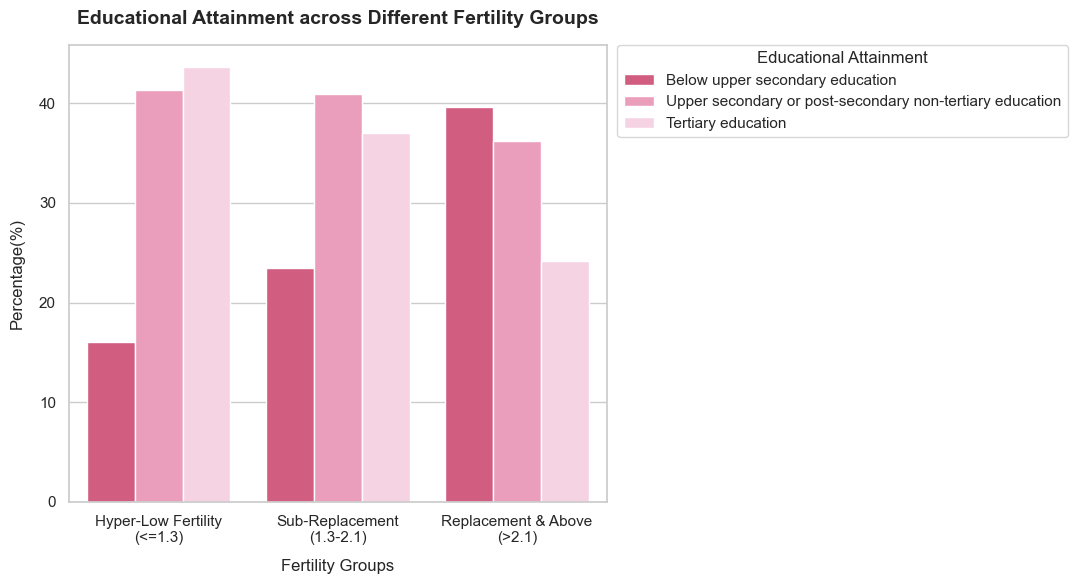

In [45]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE

import seaborn as sns

new_labels = ["Hyper-Low Fertility\n(<=1.3)", "Sub-Replacement\n(1.3-2.1)", "Replacement & Above\n(>2.1)"]

df_plot = df_groupby_analysis["mean"].unstack().reindex(columns=desired_order)
df_plot.index = new_labels
df_plot = df_plot.reset_index().rename(columns={"index": "fertility_group"})


df_melted = df_plot.melt(
    id_vars="fertility_group", 
    var_name="Educational Attainment", 
    value_name="Percentage"
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

pink_palette = ["#E44A78", "#F791BA", "#FCCDE2"]

ax = sns.barplot(
    data=df_melted,
    x="fertility_group",
    y="Percentage",
    hue="Educational Attainment",
    palette=pink_palette
)

plt.title("Educational Attainment across Different Fertility Groups", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Fertility Groups", fontsize=12, labelpad=10)
plt.ylabel("Percentage(%)", fontsize=12, labelpad=10)

plt.legend(title="Educational Attainment", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

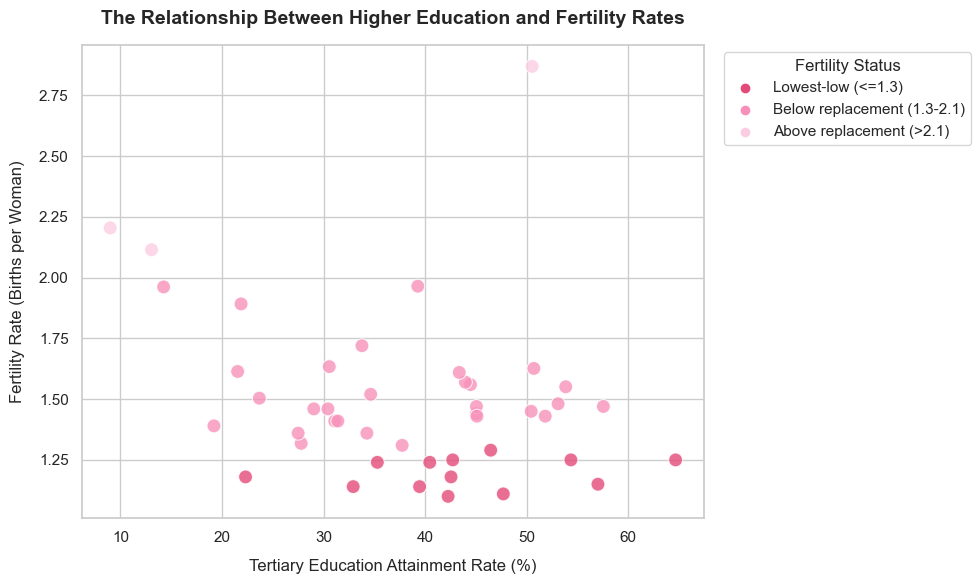

In [46]:
# Plot 2: Customized scatter plot of primary policy variables
# YOUR CODE HERE

df_scatter_data = df_merged[df_merged["educational_attainment_level"] == "Tertiary education"].copy()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_scatter_data,
    x="per cent",
    y="fertility_rate",
    hue="fertility_group",
    palette=pink_palette,
    s=100,               
    alpha=0.8            
)

plt.title("The Relationship Between Higher Education and Fertility Rates", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tertiary Education Attainment Rate (%)", fontsize=12, labelpad=10)
plt.ylabel("Fertility Rate (Births per Woman)", fontsize=12, labelpad=10)

plt.legend(title="Fertility Status", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

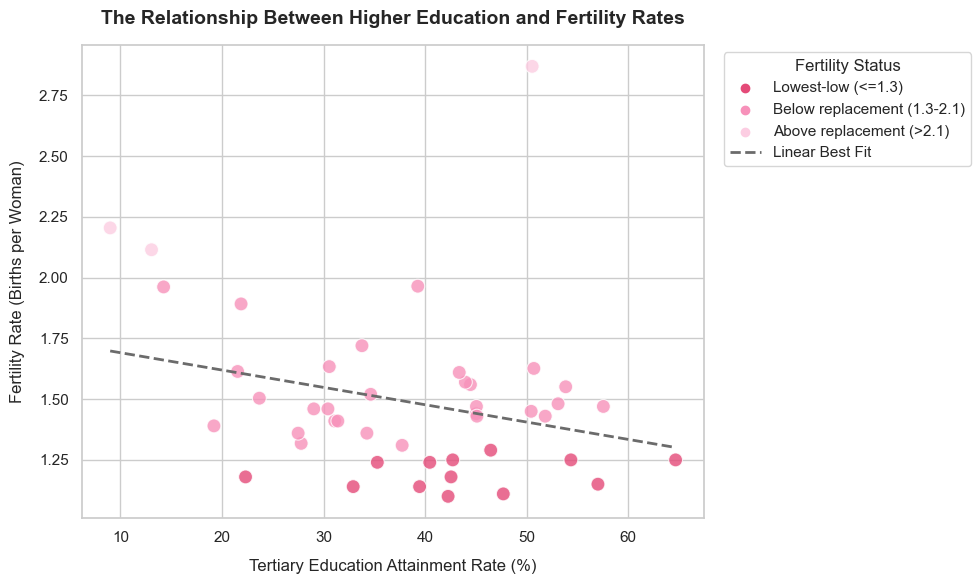

                            OLS Regression Results                            
Dep. Variable:         fertility_rate   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     3.549
Date:                Wed, 03 Jun 2026   Prob (F-statistic):             0.0664
Time:                        15:57:52   Log-Likelihood:                -12.056
No. Observations:                  45   AIC:                             28.11
Df Residuals:                      43   BIC:                             31.73
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7625      0.152     11.590      0.0

In [47]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE

import numpy as np
import statsmodels.api as sm

df_scatter_data = df_merged[df_merged["educational_attainment_level"] == "Tertiary education"].dropna(subset=["per cent", "fertility_rate"]).copy()
df_scatter_data = df_scatter_data.rename(columns={"per cent": "tertiary"})

X_reg = sm.add_constant(df_scatter_data["tertiary"])
y_reg = df_scatter_data["fertility_rate"]
fit_model = sm.OLS(y_reg, X_reg).fit()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_scatter_data,
    x="tertiary",
    y="fertility_rate",
    hue="fertility_group",
    palette=pink_palette,
    s=100,               
    alpha=0.8            
)

x_line = np.linspace(df_scatter_data["tertiary"].min(), df_scatter_data["tertiary"].max(), 100)
y_line = fit_model.predict(sm.add_constant(x_line))
plt.plot(x_line, y_line, color="#6B6B6B", linestyle="--", linewidth=2, label="Linear Best Fit")

plt.title("The Relationship Between Higher Education and Fertility Rates", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tertiary Education Attainment Rate (%)", fontsize=12, labelpad=10)
plt.ylabel("Fertility Rate (Births per Woman)", fontsize=12, labelpad=10)

plt.legend(title="Fertility Status", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(fit_model.summary())


### **Interpretation of Results**

- **Visual Findings**
  - Summarize what the charts reveal about the policy issue.
- **Model Interpretation**
  - Interpret the slope coefficient from the regression.
  - Explain what the coefficient implies in real-world public policy terms.

- *Write your visualization and regression interpretations here*

Both the bar chart and the scatter plot reveal a clear negative relationship between education and fertility. As educational achievement transitions toward higher levels, specifically Tertiary education, the national fertility rate declines, showing a structural trade-off between human capital accumulation and population replacement.

The slope coefficient for tertiary is -0.0071 (p=0.066, statistically significant at the 10% level). This indicates that, holding all else constant, a 1 percentage point increase in the tertiary education attainment rate is associated with a decrease of 0.0071 births per woman in the national fertility rate.

In real-world policy terms, this implies that expanding higher education inherently raises the opportunity cost of childbearing. To effectively increase fertility rates, policymakers must prioritise and address the underlying structural factors driven by human capital expansion. Specifically, by transforming rigid labour market norms, eliminating the motherhood career penalty, and guaranteeing workplace flexibility, thereby reshaping the socioeconomic environment to support highly educated individuals in reconciling career growth with family life.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the datasets are saved and committed in Git.
  - Ensure all files are loaded using relative paths from the project root.
  - Double-check that your primary dataset (and custom secondary dataset, if any) is saved in the local path `data/hw/hw_3/`.
  - Confirm that no absolute local paths (e.g., `/Users/username/...`) are used in any loading or saving step.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.
- **Clean Code Hygiene**
  - Ensure intermediate debug prints are removed and the notebook is polished.